In [1]:
import torch
import torchaudio
import sys
from pathlib import Path
from IPython.display import Audio

sys.path.append(str(Path.cwd() / "stablecodec"))
from stable_codec import StableCodec

device = 'cuda'

codec_model = StableCodec(
    model_config_path="/home/appleseed/Desktop/frampton/dirt-tts/checkpoints/model_config.json",
    ckpt_path="/home/appleseed/Desktop/frampton/dirt-tts/checkpoints/model.ckpt",
    device = device
)
codec_model.set_posthoc_bottleneck("1x46656_400bps")

Loading config from `/home/appleseed/Desktop/frampton/dirt-tts/checkpoints/model_config.json`.



/home/appleseed/Desktop/frampton/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Loading weights from `/home/appleseed/Desktop/frampton/dirt-tts/checkpoints/model.ckpt`.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_parquet('/home/appleseed/Desktop/frampton/data/emilia-yodas_200.parquet')
#scores = pd.read_parquet('/home/appleseed/Desktop/frampton/data/emilia_spkr_synth_scores_200.parquet')

#df['phone_density'] = df['phone_count'] / df['duration']
#df_merged = pd.merge(df, scores, left_on='speaker', right_on='speaker_id')


## find high quality subset
1. remove likely synthetic examples based on syntheticness score
2. remove likely incorrectly transcribed examples based on inferred speaking speeds
3. undersample a subset to make the duration approx normally distributed
4. remove anything else with quality score below threshold
5. make sure no speaker appears more than n times
6. add augmentation and whisperd transcriptions
7. (maybe) compute embeddings to enforce semantic diversity

In [ ]:
# 1. remove likely synthetic examples
df_merged = df_merged[df_merged['prob_mean'] < 0.15]
df_merged = df_merged.reset_index()

In [6]:
# 2. filter out impossibly fast/slow inferred speaking speeds likely due to incorrect transcription
df_clean = df_merged[(df_merged['phone_density'] >= 5) & (df_merged['phone_density'] <= 25)]

In [73]:
# 3. make durations approx normally distributed
df_clean['bin'] = pd.cut(df_clean['duration'], bins=20)
minbin = df_clean['bin'].value_counts().min()
df_clean_subset = (df_clean.groupby('bin', group_keys=False).sample(n=minbin, random_state=42))
print(df_clean['bin'].value_counts())

/tmp/ipykernel_3100912/1342935593.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['bin'] = pd.cut(df_clean['duration'], bins=20)
/tmp/ipykernel_3100912/1342935593.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clean_subset = (df_clean.groupby('bin', group_keys=False).sample(n=minbin, random_state=42))


bin
(2.973, 4.35]    453894
(4.35, 5.7]      425127
(5.7, 7.05]      400438
(7.05, 8.4]      347461
(8.4, 9.75]      287278
(9.75, 11.1]     235446
(11.1, 12.45]    189610
(12.45, 13.8]    159620
(13.8, 15.15]    133301
(15.15, 16.5]    116234
(16.5, 17.85]    101889
(17.85, 19.2]     88133
(19.2, 20.55]     61640
(20.55, 21.9]     27478
(21.9, 23.25]     18399
(28.65, 30.0]     15443
(23.25, 24.6]     11804
(24.6, 25.95]      8504
(27.3, 28.65]      8409
(25.95, 27.3]      7211
Name: count, dtype: int64


In [74]:
# 4. quality filter
df_cleaner = df_clean_subset[df_clean_subset['dnsmos'] >= 3.5]
df_cleaner

,index,text,duration,speaker,dnsmos,phone_count,id,tokens,phone_density,speaker_id,prob_mean,prob_min,prob_max,prob_confidence,bin
1243833,2108990,"And again, we need stop propagation and, uh, p...",3.38,EN_5Z6HWmezUac_SPEAKER_00,3.5187,56,EN_5Z6HWmezUac_W000043,"[19817, 13099, 27556, 41864, 30292, 25460, 147...",16.568047,EN_5Z6HWmezUac_SPEAKER_00,0.120914,0.001457,0.305133,4,"(2.973, 4.35]"
1407124,2376328,I woke up and I looked at the phone. It was 253.,3.17,EN_rPsktf0R574_SPEAKER_00,3.5055,56,EN_rPsktf0R574_W000011,"[25774, 1793, 12590, 38282, 46028, 36202, 2535...",17.665615,EN_rPsktf0R574_SPEAKER_00,0.121040,0.000065,0.454033,4,"(2.973, 4.35]"
89750,156773,I had been verbally abused and physically abus...,4.06,EN_FF2nKwGFfyA_SPEAKER_24,3.5440,52,EN_FF2nKwGFfyA_W000054,"[2298, 581, 11236, 34059, 2125, 13445, 38308, ...",12.807882,EN_FF2nKwGFfyA_SPEAKER_24,0.037917,0.021897,0.053937,2,"(2.973, 4.35]"
393268,668508,into the top four and thereby get the nice frame.,4.03,EN_ilbhKoTCLag_SPEAKER_00,3.5944,40,EN_ilbhKoTCLag_W000033,"[5684, 9415, 35327, 27470, 27343, 12210, 18724...",9.925558,EN_ilbhKoTCLag_SPEAKER_00,0.048895,0.032639,0.057878,4,"(2.973, 4.35]"
796133,1346070,"Mr. Turner, what were your actions after you s...",4.14,EN_1Co6wXioH4U_SPEAKER_13,3.5335,58,EN_1Co6wXioH4U_W000058,"[9882, 35907, 174, 32531, 5539, 2924, 21262, 3...",14.009662,EN_1Co6wXioH4U_SPEAKER_13,0.138297,0.000032,0.521895,4,"(2.973, 4.35]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292264,498010,"Alright. Listen, we love everybody. Thank you ...",30.00,EN_OZ4AR8gcj7u_SPEAKER_00,3.5214,511,EN_OZ4AR8gcj7u_W000254,"[4843, 3287, 9843, 12356, 29387, 26756, 19915,...",17.033333,EN_OZ4AR8gcj7u_SPEAKER_00,0.001138,0.000348,0.002679,4,"(28.65, 30.0]"
1465085,2472524,that's why I came down today. And I think we'r...,30.00,EN_FKSgzdKUx5U_SPEAKER_00,3.5548,535,EN_FKSgzdKUx5U_W000009,"[3355, 9333, 4379, 6793, 11781, 26534, 30296, ...",17.833333,EN_FKSgzdKUx5U_SPEAKER_00,0.131743,0.026776,0.206666,4,"(28.65, 30.0]"
1166310,1978780,There you have a certain democratization of th...,29.92,EN_nyIC7T4EXXg_SPEAKER_00,3.5469,281,EN_nyIC7T4EXXg_W000023,"[24584, 19926, 23065, 17363, 38975, 39460, 358...",9.391711,EN_nyIC7T4EXXg_SPEAKER_00,0.149903,0.007490,0.338654,4,"(28.65, 30.0]"
2261628,3696862,A community activist. And she didn't know that...,29.58,EN_RSbz3dftAS4_SPEAKER_01,3.5013,306,EN_RSbz3dftAS4_W000090,"[14937, 11177, 11289, 21769, 5975, 20243, 4034...",10.344828,EN_RSbz3dftAS4_SPEAKER_01,0.039578,0.000157,0.065890,4,"(28.65, 30.0]"


In [78]:
rand_idx = 1978780
df_toks = df.iloc[rand_idx]['tokens']
df_toks = torch.tensor(df_toks).unsqueeze(0).unsqueeze(-1).to(device)
dec_audio = codec_model.decode([df_toks], posthoc_bottleneck=True)
dec_audio = dec_audio[0, :, :].cpu()

print(df.iloc[rand_idx]['text'])
print(dec_audio.shape)
Audio(dec_audio.float().numpy(), rate=16000, autoplay=True)

There you have a certain democratization of the truth happening, of access to the truth in this culture. But of course, even up to today, we still have the institutional models for legitimizing or delegitimizing truths. We have the dominance discourses about truth and the subjects that are considered to be more or less capable of truth discourses.
torch.Size([1, 478720])


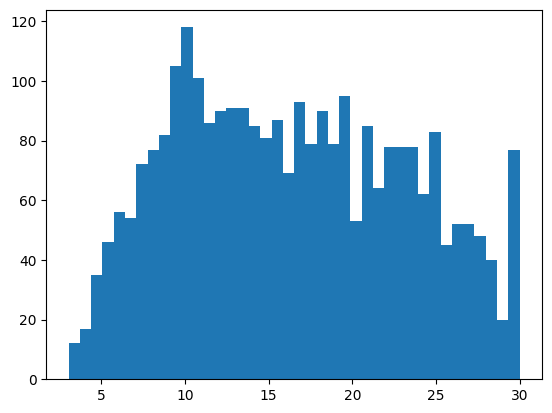

In [75]:
plt.hist(df_cleaner['duration'], bins=40)
plt.show()

## top spkrs

In [3]:
spkr_durs = df_merged.groupby("speaker").agg({
    "duration": "sum",
    "id": "count",
})
spkr_durs = spkr_durs.sort_values(by='duration', ascending=False).reset_index()
spkr_durs

,speaker,duration,id
0,EN_kndf_eGeTYI_SPEAKER_00,8147.90,1008
1,EN_e4P4SVnARmo_SPEAKER_00,7397.41,499
2,EN_xqaGCQbIQdY_SPEAKER_00,7017.82,468
3,EN_r3EWyspLruI_SPEAKER_00,6640.74,567
4,EN_y0f0JhsH_ho_SPEAKER_06,6284.35,368
...,...,...,...
129229,EN_z_KFPtPtMWM_SPEAKER_10,3.00,1
129230,EN_pYNV2KSprbg_SPEAKER_01,3.00,1
129231,EN_hKALgSR9OCo_SPEAKER_14,3.00,1
129232,EN_Mas1to3BmdY_SPEAKER_00,3.00,1


In [152]:
top_n = spkr_durs.iloc[11]
print(top_n)
df_merged[df_merged['speaker'] == top_n['speaker']].sample()

speaker     EN_b4v9CaGMhF0_SPEAKER_00
duration                      5555.61
id                                703
Name: 11, dtype: object


,index,text,duration,speaker,dnsmos,phone_count,id,tokens,speaker_id,prob_mean,prob_min,prob_max,prob_confidence
3019280,4819910,"Yeah, that appears to be. And, and, yeah, I re...",4.29,EN_b4v9CaGMhF0_SPEAKER_00,2.7794,58,EN_b4v9CaGMhF0_W000104,"[41096, 16298, 45125, 45806, 10901, 2886, 2228...",EN_b4v9CaGMhF0_SPEAKER_00,0.002046,0.000008,0.00403,4


In [153]:
rand_idx = 3019280
df_toks = df_merged.iloc[rand_idx]['tokens']
df_toks = torch.tensor(df_toks).unsqueeze(0).unsqueeze(-1).to(device)
dec_audio = codec_model.decode([df_toks], posthoc_bottleneck=True)
dec_audio = dec_audio[0, :, :].cpu()

print(df_merged.iloc[rand_idx]['text'])
print(dec_audio.shape)
Audio(dec_audio.float().numpy(), rate=16000, autoplay=True)

Yeah, that appears to be. And, and, yeah, I really appreciate this thing of...
torch.Size([1, 69120])


## token frequencies

In [7]:
all_tokens = np.concatenate(df['tokens'].values)
counts = pd.Series(all_tokens).value_counts().sort_index()
counts

0         879
1        1302
2        1382
3        1350
4        1393
         ... 
46651     709
46652     201
46653     287
46654      60
46655      24
Name: count, Length: 46656, dtype: int64

In [10]:
counts.sort_values()

45574         1
45568         1
37798         2
45562         3
45544         5
          ...  
14758    453219
4279     455710
5504     550492
5503     584060
5539     611776
Name: count, Length: 46656, dtype: int64

In [8]:
from collections import Counter
freq = np.zeros(46656, dtype=np.int64)
for arr in df['tokens']:
    freq += np.bincount(arr, minlength=46656)

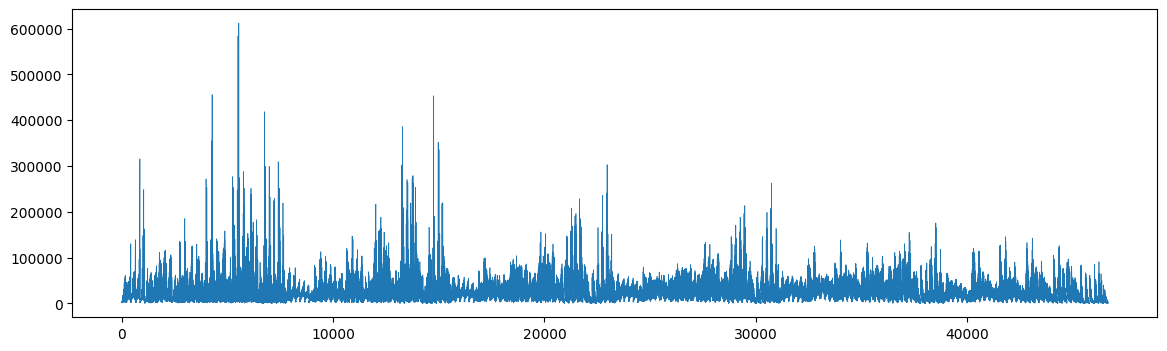

In [9]:
plt.figure(figsize=(14, 4))
plt.plot(freq, linewidth=0.5)
plt.show()

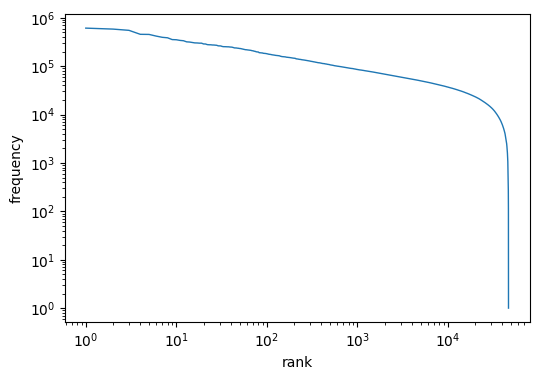

In [14]:
sorted_freq = np.sort(freq)[::-1]
rank = np.arange(1, len(sorted_freq) + 1)
plt.figure(figsize=(6, 4))
plt.loglog(rank, sorted_freq, linewidth=1)
plt.xlabel('rank')
plt.ylabel('frequency')
plt.show()

EN_1DcAwr4AY6c_SPEAKER_01 7


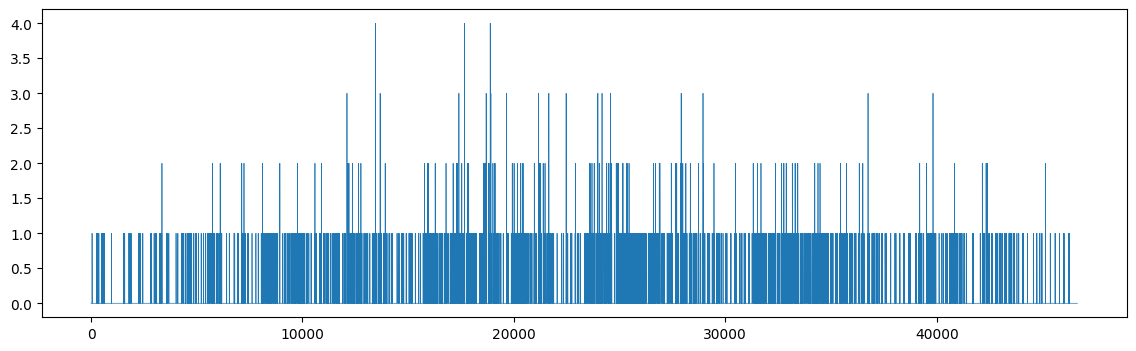

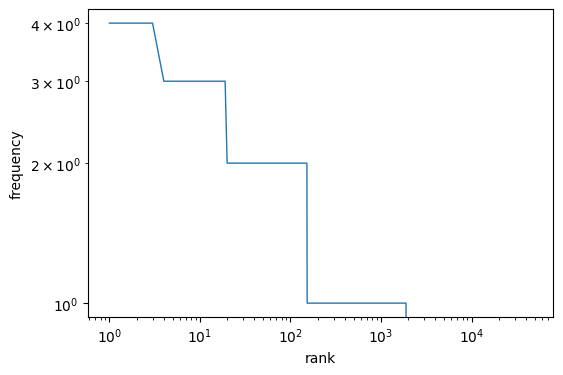

In [29]:
rand_spkr = pd.Series(df['speaker'].unique()).sample().iloc[0]
freq = np.zeros(46656, dtype=np.int64)
for cung, arr in enumerate(df[df['speaker'] == rand_spkr]['tokens']):
    freq += np.bincount(arr, minlength=46656)

print(rand_spkr, cung)

plt.figure(figsize=(14, 4))
plt.plot(freq, linewidth=0.5)
plt.show()

sorted_freq = np.sort(freq)[::-1]
rank = np.arange(1, len(sorted_freq) + 1)
plt.figure(figsize=(6, 4))
plt.loglog(rank, sorted_freq, linewidth=1)
plt.xlabel('rank')
plt.ylabel('frequency')
plt.show()

## durations and speaking speed

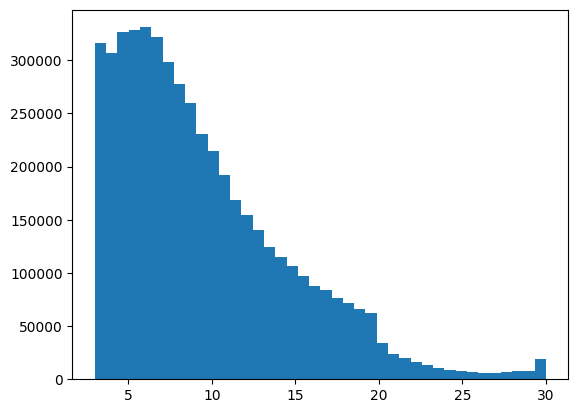

In [19]:
plt.hist(df['duration'], bins=40)
plt.show()

In [28]:
df.sort_values(by='phone_density')

,text,duration,speaker,dnsmos,phone_count,id,tokens,phone_density
930316,the,30.00,EN_r2ZwW81tqA8_SPEAKER_01,3.2907,2,EN_r2ZwW81tqA8_W000048,"[12608, 32981, 12434, 13940, 44333, 44090, 145...",0.066667
964328,ee.,30.00,EN__aRnsEkVpXQ_SPEAKER_00,3.2067,2,EN__aRnsEkVpXQ_W000021,"[3627, 8254, 34847, 21995, 17335, 4374, 4852, ...",0.066667
884834,"so,",30.00,EN_cSBKHMbI69k_SPEAKER_00,3.2059,3,EN_cSBKHMbI69k_W000006,"[14941, 9407, 22564, 12248, 35516, 22832, 3387...",0.100000
2955641,"So,",30.00,EN_F5lHgDJ7ydM_SPEAKER_00,3.0639,3,EN_F5lHgDJ7ydM_W000000,"[11101, 26513, 19917, 11707, 27338, 12647, 247...",0.100000
1516267,"so,",30.00,EN_h0ifyKkO7iQ_SPEAKER_00,3.2121,3,EN_h0ifyKkO7iQ_W000019,"[25861, 10289, 20628, 33371, 40462, 46088, 269...",0.100000
...,...,...,...,...,...,...,...,...
222459,ビーバー・アッパー・ラン・トゥルー・ヘアー・ヘバー、エイト・ヤング・マンカ・パイ・カブザーラ...,10.32,EN_BSrookmkpFg_SPEAKER_02,3.3993,1080,EN_BSrookmkpFg_W000015,"[1944, 10813, 13626, 22960, 40541, 37178, 4092...",104.651163
2778846,あのう、ど、し、ちょん、は、じゅ、し、や、さ、が、ん、そ、は、ば、ね、だ、だ、く、じゃ、や、...,12.57,EN_n9loVsw_ipE_SPEAKER_02,3.0516,1320,EN_n9loVsw_ipE_W000005,"[11599, 21431, 19912, 25213, 18727, 19513, 330...",105.011933
2643035,ハックスープユールハンドアゴビーヤックジャックインハイアングサングユールハーギハードハンチャ...,12.00,EN_0ZpcqDZK7LE_SPEAKER_03,3.0634,1356,EN_0ZpcqDZK7LE_W000002,"[11487, 28959, 3116, 7925, 1269, 12759, 6244, ...",113.000000
994537,"フィトファカダ, エレイアティバリー, アルサビキ, ファイアイジバリー, アルムサフィリー...",17.69,EN_rqABiF1lPNA_SPEAKER_00,3.1814,2015,EN_rqABiF1lPNA_W000124,"[21428, 6416, 44327, 25016, 14718, 5703, 13865...",113.906162


In [17]:
rand_idx = 930316
df_toks = df.iloc[rand_idx]['tokens']
df_toks = torch.tensor(df_toks).unsqueeze(0).unsqueeze(-1).to(device)
dec_audio = codec_model.decode([df_toks], posthoc_bottleneck=True)
dec_audio = dec_audio[0, :, :].cpu()

print(df.iloc[rand_idx]['text'])
print(dec_audio.shape)
Audio(dec_audio.float().numpy(), rate=16000, autoplay=True)

the
torch.Size([1, 480000])


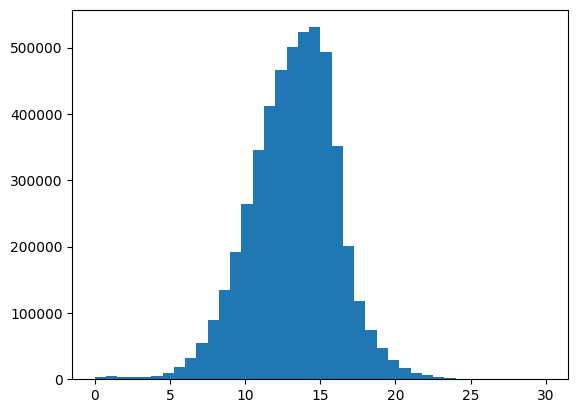

In [31]:
plt.hist(df['phone_density'], bins=40, range=(0, 30))
plt.show()

In [37]:
df[df['text'].apply(lambda x: x.isalnum() == True)]

,text,duration,speaker,dnsmos,phone_count,id,tokens,phone_density
121004,verla,30.00,EN_CqPjnFiuntE_SPEAKER_00,3.1170,4,EN_CqPjnFiuntE_W000003,"[4610, 20405, 25409, 18493, 13920, 3932, 13245...",0.133333
162170,Quaternary,30.00,EN_FlmPfp9uM9A_SPEAKER_00,3.2812,9,EN_FlmPfp9uM9A_W000009,"[4931, 10336, 2489, 325, 27814, 20418, 18075, ...",0.300000
306109,nani,30.00,EN_FK3Tr_ORFJM_SPEAKER_00,3.3559,4,EN_FK3Tr_ORFJM_W000001,"[5895, 20153, 10665, 22317, 26721, 27729, 3132...",0.133333
368864,eueueueue,30.00,EN_IIVIsnayrA4_SPEAKER_00,3.3201,8,EN_IIVIsnayrA4_W000047,"[13527, 18914, 3347, 13611, 12532, 5145, 34635...",0.266667
523262,eqf,7.20,EN_PdO7IWsDuiU_SPEAKER_06,3.2642,3,EN_PdO7IWsDuiU_W000042,"[35221, 22826, 33887, 3156, 5245, 14971, 4906,...",0.416667
930316,the,30.00,EN_r2ZwW81tqA8_SPEAKER_01,3.2907,2,EN_r2ZwW81tqA8_W000048,"[12608, 32981, 12434, 13940, 44333, 44090, 145...",0.066667
1156152,Banishes,7.11,EN_FadWmRppLgy_SPEAKER_00,3.0706,7,EN_FadWmRppLgy_W000041,"[7448, 10876, 2879, 601, 32535, 31472, 17057, ...",0.984529
1315057,Spockit,30.00,EN_XPefoFkXha0_SPEAKER_00,3.0854,6,EN_XPefoFkXha0_W000010,"[3399, 20397, 10109, 19573, 13021, 19573, 1304...",0.200000
1315115,Unlimited,30.00,EN_XPefoFkXha0_SPEAKER_00,3.2429,9,EN_XPefoFkXha0_W000035,"[2329, 4403, 12993, 36765, 14118, 23232, 24959...",0.300000
1333087,for,14.43,EN_0vQg3V2v1kA_SPEAKER_00,3.1397,2,EN_0vQg3V2v1kA_W000001,"[5138, 28119, 36149, 9337, 25450, 28022, 34719...",0.138600


In [57]:
rand_idx = 4469445
df_toks = df.iloc[rand_idx]['tokens']
df_toks = torch.tensor(df_toks).unsqueeze(0).unsqueeze(-1).to(device)
dec_audio = codec_model.decode([df_toks], posthoc_bottleneck=True)
dec_audio = dec_audio[0, :, :].cpu()

print(df.iloc[rand_idx]['text'])
print(dec_audio.shape)
Audio(dec_audio.float().numpy(), rate=16000, autoplay=True)

Y1Y2Y3Y4Y1Y2Y3Y5Y1Y2Y4Y5Y1Y3Y4Y5Y2Y3Y4Y5S5
torch.Size([1, 269440])
